## Setup

In [1]:
from vectorbtpro import *
import os
import sys

from zoneinfo import ZoneInfo
from datetime import datetime
from dateutil.relativedelta import relativedelta

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Latex

In [2]:
sys.path.insert(0, os.getcwd())

from strategy import ADX, KAMA, get_adx_di, get_kama, generate_signals, get_signals_analysis, plot_strategy
from strategy import nb_chunked, pipeline_nb
from utils import calc_returns

## Market Data

Retrieve market data for three assets (BTCUSD, ETHUSD) using YahooFinance's free API, and save the price-series locally. We will examine price-series going back 2 years on three cryptocurrencies, four tech-stocks, whilst using the S&P 500 ETF Trust, Investico QQQ ETF Trust (tracks the NASDAQ 100 index) as benchmarks for comparisons.

In [3]:
os.environ["TZ"] = "UTC"
END_DATE = datetime.now(ZoneInfo("UTC")).strftime("%Y-%m-%d")
START_DATE = (datetime.now(ZoneInfo("UTC")) - relativedelta(years=3)).strftime("%Y-%m-%d")

In [4]:
print(f"{START_DATE} to {END_DATE}")

2023-04-21 to 2026-04-21


In [5]:
cryptos = vbt.YFData.pull(
    ["BTC-USD", "ETH-USD", "SOL-USD"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz_convert="UTC",
    tz_localize="UTC",
    
)

stocks = vbt.YFData.pull(
    ["TSLA", "AAPL", "MSFT", "NVDA"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz_convert="UTC",
    missing_index="NaN",
    tz_localize="UTC",
)

market_data = stocks.realign(ffill=True)
market_data = market_data.merge(cryptos).dropna()

In [6]:
benchmarks = vbt.YFData.pull(
    ["QQQ", "SPY"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz="UTC"
)
bm_close = benchmarks.get('Close')
bm_close.index = bm_close.index.normalize() # remove market close timestamp

## Indicators

### Average Directional Momentum Index (ADX)

Let $L_t,H_t$ be stochastic processes representing the daily low price, high price.

Let $W^{\pm}_t$ represent the plus and minus directional index (+DI and -DI), respectively, given by 
$$
W^+_t=
\begin{cases}
\Delta H_t &\text{if}\quad\Delta H_t > 0\;\text{and}\; \Delta H_t > \Delta L_t\\
0 &\text{otherwise,}
\end{cases}\qquad
W^-_t=
\begin{cases}
\Delta L_t &\text{if}\quad\Delta L_t > 0\;\text{and}\; \Delta L_t >  \Delta H_t \\
0 &\text{otherwise.}
\end{cases}
$$

where $\Delta = (1-B)$ where $B$ is the backshift operator.

Let $T_t=\max\{H_t,L_{t-1}\} - \min\{L_t,C_{t-1}\}$ represent the Wilder true range, then calculate the average true range $A_t$ using a lookback window of length $N_A$. Next, we calculate averages $Z^{\pm}_t$ from the plus and minus direction indices with lookback windows of $N_+=N_-=14$.
$$
A_t = \sum_{i=0}^{N_A-1} T_{t-i},
\qquad
Z^{\pm}_t=\frac{100}{N^*}\sum_{i=0}^{N^*} \frac{W^{\pm}_{t-i}}{A_{t-i}}
$$

Finally, we calculate the average direction index by computing another average with adx lookback window $N$ as follows
$$
\text{ADX}_t=\frac{100}{N}\sum_{i=0}^{N} \frac{|Z^+_{t-i}-Z^-_{t-i}|}{|Z^+_{t-i}+Z^-_{t-i}|}
$$

Note that the ADX lookback window $N$ is a model parameter (`adx_ma_len`), for which we will be finding the optimal value. This function is implemented in `get_adx_di` in Numpy with Numba-acceleration, and a custom class is derived from the following vector-bt indictor factory.
```
ADX = vbt.IF(
    class_name = 'Average Directional Momentum Index',
    short_name = 'ADX',
    input_names = ['high', 'low', 'close'], 
    param_names = ['di_ma_len', 'adx_ma_len'],
    output_names = ['adx', 'plus_di', 'minus_di']
).with_apply_func(
    get_adx_di,
    takes_1d=True,
    di_ma_len=14,
    adx_ma_len=20
)
```

### Kaufmann Adaptive Moving Average (KAMA)

Let $X_t$ be a stochastic process representing the daily closing price. 
The efficiency ratio is calculated over a lookback window of length $n$, and is given by 
$$
\text{ER}_t = \frac{|X_t - X_{t-n}|}{\displaystyle\sum_{i=0}^{n-1}|X_{t-i} - X_{t-i-1}|} 
$$
Next, the "smoothing constant" $\text{SC}_t$ combines fast a slow EMA smoothing, where fast and slow constants $s$ and $f$, respectively, are model parameters (`fast_ma_len` and `slow_ma_len`) whose optimal values will be calculated later.
$$
\text{SC}_t = \left[\text{ER}_t \cdot \left(\frac{2}{f+1} - \frac{2}{s+1}\right) + \frac{2}{s+1}\right]^2 \\[8pt]
$$
Finally, we calulate the KAMA with the following recursive formula.
$$
\text{KAMA}_t = \text{KAMA}_{t-1} + \text{SC}_t \cdot (X_t - \text{KAMA}_{t-1})
$$

This function is implemented in `get_kama` in Numpy with Numba-acceleration, and a custom class is derived from the following vector-bt indictor factory.

```
Kama = vbt.IF(
    class_name = 'Kaufmann Adaptive Moving Average',
    short_name = 'KAMA',
    input_names = ['close'], 
    param_names = ['period', 'fast_ma_len', 'slow_ma_len'],
    output_names = ['kama']
).with_apply_func(
    get_kama,
    takes_1d=True,
    period=10,
    fast_ma_len=2,
    slow_ma_len=30
)
```

### Overview

In [7]:
adx = ADX.run(market_data.get('High'), market_data.get('Low'), market_data.get('Close'))

In [8]:
kama = KAMA.run(market_data.get('Close'))

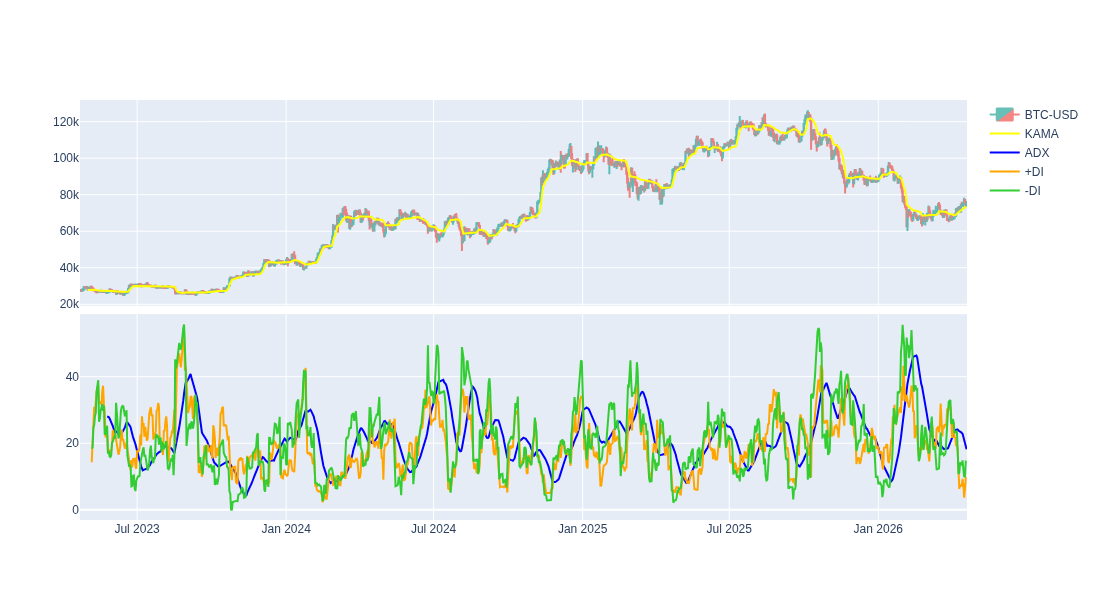

In [9]:
symbol="BTC-USD"
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)
ohlc_trace = market_data.plot(symbol=symbol, plot_volume=False, ohlc_trace_kwargs=dict(opacity=0.7)).data[0]
ohlc_trace.name = symbol
fig.add_trace(ohlc_trace, row=1, col=1)

kama.plot(column=symbol, 
    kama_kwargs=dict(line_color='yellow', name="KAMA"),
    fig=fig, row=1, col=1
)

adx.plot(column=symbol, 
    adx_kwargs=dict(line_color='blue'),
    plus_di_kwargs=dict(line_color='orange'),
    minus_di_kwargs=dict(line_color='limegreen'),
    fig=fig, row=2, col=1
)

fig.update(layout_xaxis_rangeslider_visible=False)
fig.update_layout(height=600, width=1000)

## Trading Strategy

This strategy generates a buy signal on an upwards trend change (faster KAMA crossing <b>above</b> slower KAMA) and a sell signal on a downwards trend change (faster KAMA crossing <b>below</b> slower KAMA). The ADX is used as a filter, removing buy or sell signals if below a certain threshold (i.e. the trend is not strong enough to enter the trade). 

Using vector-bt functions, we are able to calculate boolean masks of cross-overs corresponding to entries for each asset as follows 
```
entries = vbt.nb.crossed_above_1d_nb(kama_fast, kama_slow) 
exits = vbt.nb.crossed_below_1d_nb(kama_fast, kama_slow)

adx_filter = np.where(adx > adx_thrsh, 1.0, 0.0)
entries = entries * adx_filter
exits = exits * adx_filter

```

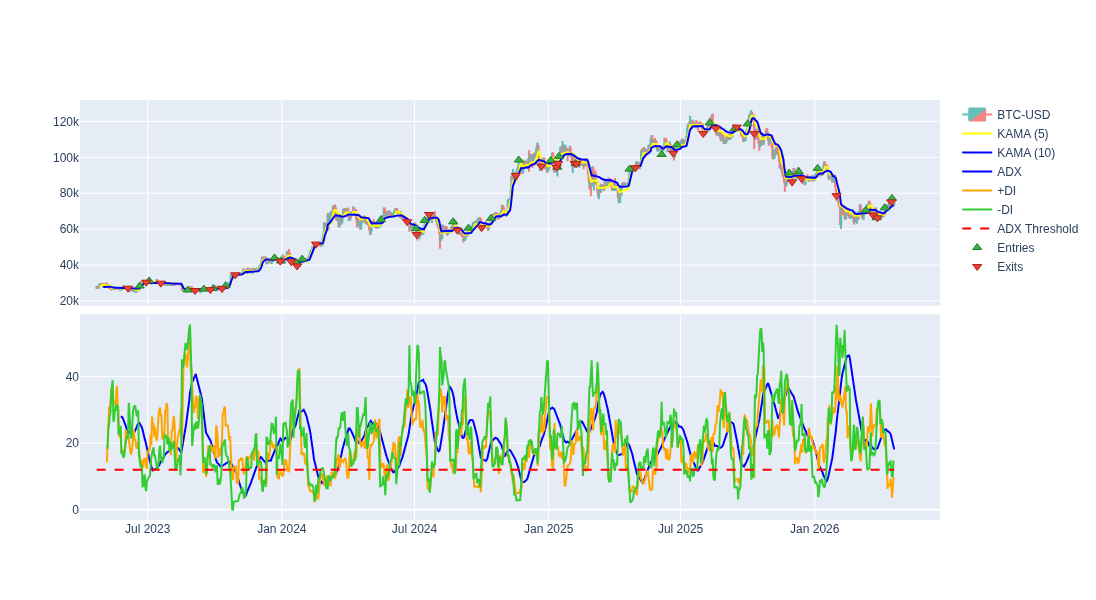

In [10]:
fig = plot_strategy(market_data,'BTC-USD')
fig.update_layout(width=1000,height=600)
fig.show()

## Backtest and Parameter Optimization

### Parameter Space

Let's define a parameter space $S$ for both the KAMA and the ADX indicators. Here $S$ is the cartesian product of all input parameter sets. 

In [11]:
kama_fast_period = np.arange(3, 15)
kama_slow_period = np.arange(15, 30)
di_ma_len = np.arange(2, 10)
adx_ma_len = np.arange(3, 15)
adx_thrsh = np.arange(10, 40, 2)

op_tree = (product, 
           kama_fast_period, 
           kama_slow_period, di_ma_len, adx_ma_len, adx_thrsh)
param_products = vbt.generate_param_combs(op_tree) 

kama_fast_period_prod = np.asarray(param_products[0])
kama_slow_period_prod = np.asarray(param_products[1])
di_ma_len_prod = np.asarray(param_products[2])
adx_ma_len_prod = np.asarray(param_products[3])
adx_thrsh_prod = np.asarray(param_products[4])

In [12]:
display(Latex(rf'$|S|=$ {market_data.shape[1]} $\times$ {kama_fast_period_prod.size} = {market_data.shape[1] * kama_fast_period_prod.size}  parameter combinations')) 

<IPython.core.display.Latex object>

### Backtesting Pipeline

Now, we construct a backtesting pipeline in order to parallelize backtesting across cores.
1. Generates trading signals based on a given parameter combination $p\in S$.
2. Simulate a portfolio $P$ with an initial investment of $K$ dollars following this strategy on the training period.
3. Calculates metrics and counts the number of orders for portfolio $P$ as follows (annualization factor `ann_factor=365` trading days for crypto markets)

   ```
   sharpe = vbt.ret_nb.sharpe_ratio_nb(returns, ann_factor, ddof=1)
   sortino = vbt.ret_nb.sortino_ratio_nb(returns, ann_factor)
   dd = vbt.ret_nb.max_drawdown_nb(returns, ann_factor)
   metrics_vec = np.column_stack((sharpe, sortino, dd, num_trades))
   ```

The <u>nogil=True</u> argument in the @njit decorator allows the Python Global Interpreter Lock (GIL) to be released during computation, enabling the execution of independent tasks across multiple threads simultaneously. Dask then partitions the workload into manageable tasks and schedules them across the cores. Each task computes portfolios for a mutually-exclusive subset of parameter space $S$. Overall, this chunked pipeline leverages both Numba's JIT compilation for per-portfolio calculations and Dask's distributed execution capabilities for multi-core parallelism. 

In [13]:
%%time
chunked_pipeline_nb = nb_chunked(pipeline_nb)
res = chunked_pipeline_nb(
    market_data.get('High').values, market_data.get('Low').values, market_data.get('Close').values,
    kama_fast_period=kama_fast_period_prod, 
    kama_slow_period=kama_slow_period_prod, 
    adx_ma_len=adx_ma_len_prod,
    adx_thrsh=adx_thrsh_prod,
    di_ma_len=di_ma_len_prod,
    ann_factor=365,
    _execute_kwargs=dict(engine="dask"),
    _merge_kwargs=dict(input_columns=market_data.get('Close').columns)
)

CPU times: user 30min 44s, sys: 1.03 s, total: 30min 45s
Wall time: 2min 6s


With 22 cores, we are able to backtest $|S|=1814400$ parameter combinations in under 3 minutes.

## Analysis

The objective of the backtest was to find a parameter combination that under our ruleset leads to a strategy that places at least $M=15$ orders and has no more than a $30\%$ maximum drawdown over the training period. After filtering, here are the top 10 performing portfolios across all assets using this strategy trained over data from the past 3 years.

In [14]:
res = res[res['DD'] > -0.30] 
res = res[res['Num Trades'] > 15] 
best_portfolios = res.sort_values(by=['Sortino'], ascending=False)
display(best_portfolios.head(10))

Sharpe  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               17               7         6          12        SOL-USD  1.876319   
10               15               7         4          10        NVDA     2.074552   
14               17               6         7          12        SOL-USD  1.826770   
10               15               8         3          10        NVDA     1.988353   
9                16               6         4          12        NVDA     1.965172   
14               17               7         7          14        SOL-USD  1.746040   
                                  6         8          14        SOL-USD  1.746040   
9                16               8         4          10        NVDA     1.899508   
7                19               7         5          10        NVDA     1.876656   
9                16               6         3          10        NVDA     1.961510   

                                                                           Sortino  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               17               7         6          12        SOL-USD  3.805207   
10               15               7         4          10        NVDA     3.730956   
14               17               6         7          12        SOL-USD  3.672879   
10               15               8         3          10        NVDA     3.545226   
9                16               6         4          12        NVDA     3.470432   
14               17               7         7          14        SOL-USD  3.445301   
                                  6         8          14        SOL-USD  3.445301   
9                16               8         4          10        NVDA     3.324451   
7                19               7         5          10        NVDA     3.294879   
9                16               6         3          10        NVDA     3.285544   

                                                                                DD  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               17               7         6          12        SOL-USD -0.233945   
10               15               7         4          10        NVDA    -0.201109   
14               17               6         7          12        SOL-USD -0.272573   
10               15               8         3          10        NVDA    -0.201109   
9                16               6         4          12        NVDA    -0.174535   
14               17               7         7          14        SOL-USD -0.251396   
                                  6         8          14        SOL-USD -0.251396   
9                16               8         4          10        NVDA    -0.174535   
7                19               7         5          10        NVDA    -0.211252   
9                16               6         3          10        NVDA    -0.173868   

                                                                          Num Trades  
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol               
14               17               7         6          12        SOL-USD        19.0  
10               15               7         4          10        NVDA           20.0  
14               17               6         7          12        SOL-USD        20.0  
10               15               8         3          10        NVDA           18.0  
9                16               6         4          12        NVDA           16.0  
14               17               7         7          14        SOL-USD        18.0  
                                  6         8          14        SOL-USD        18.0  
9                16               8         4          10        NVDA           16.0  
7                19               7         5          10        NVDA           20.0  
9                16 

Fitting this strategy to the past three years' data showed best performance on Nvidia and Solana. We now analyze and evaluate the strategy with the parameter combination, which led to the best sortino ratio in backtests.

In [15]:
inputs = best_portfolios.iloc[0].name
opt_params = dict(
    kama_fast_period = inputs[0],
    kama_slow_period = inputs[1],
    di_ma_len = inputs[2],
    adx_ma_len = inputs[3],
    adx_thrsh = inputs[4],
)

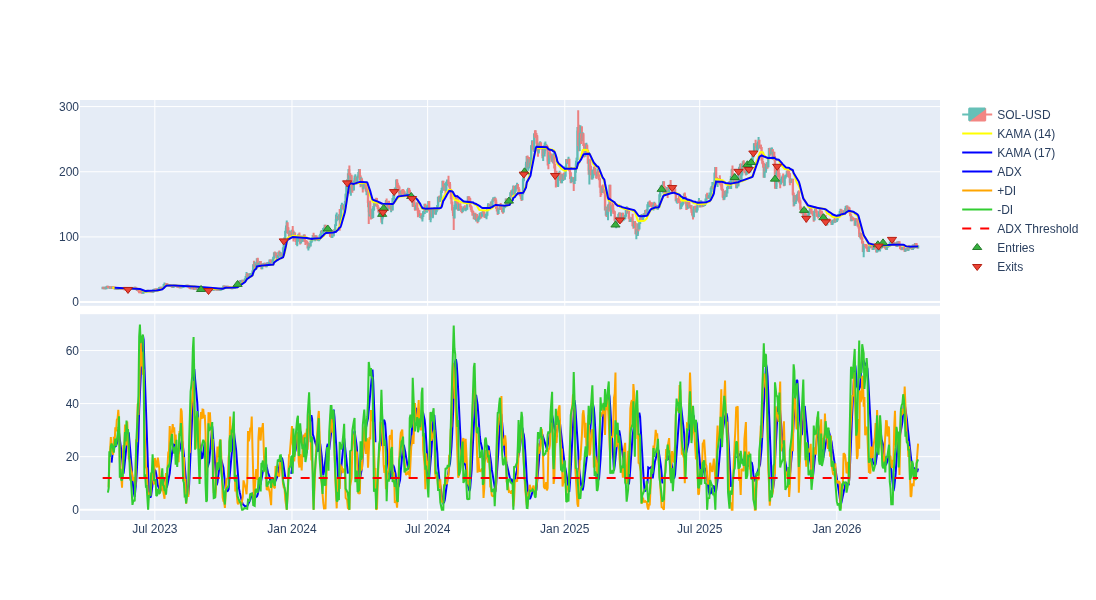

In [16]:
fig=plot_strategy(market_data,'SOL-USD', ind_params=opt_params)
fig.update_layout(width=1000,height=600)
fig.show()

In [17]:
kama_fast = KAMA.run(market_data.get('Close'), period=opt_params['kama_fast_period'])
kama_slow = KAMA.run(market_data.get('Close'), period=opt_params['kama_slow_period'])
adx = adx.run(market_data.get('High'), market_data.get('Low'), market_data.get('Close'), 
              di_ma_len=opt_params['di_ma_len'],
              adx_ma_len=opt_params['adx_ma_len'])
adx_thrsh= opt_params['adx_thrsh']

signals = get_signals_analysis(kama_fast, kama_slow, adx, adx_thrsh)
pf1 = vbt.Portfolio.from_signals(
    market_data.get('Close'),
    entries=signals[0],
    exits=signals[1]
)

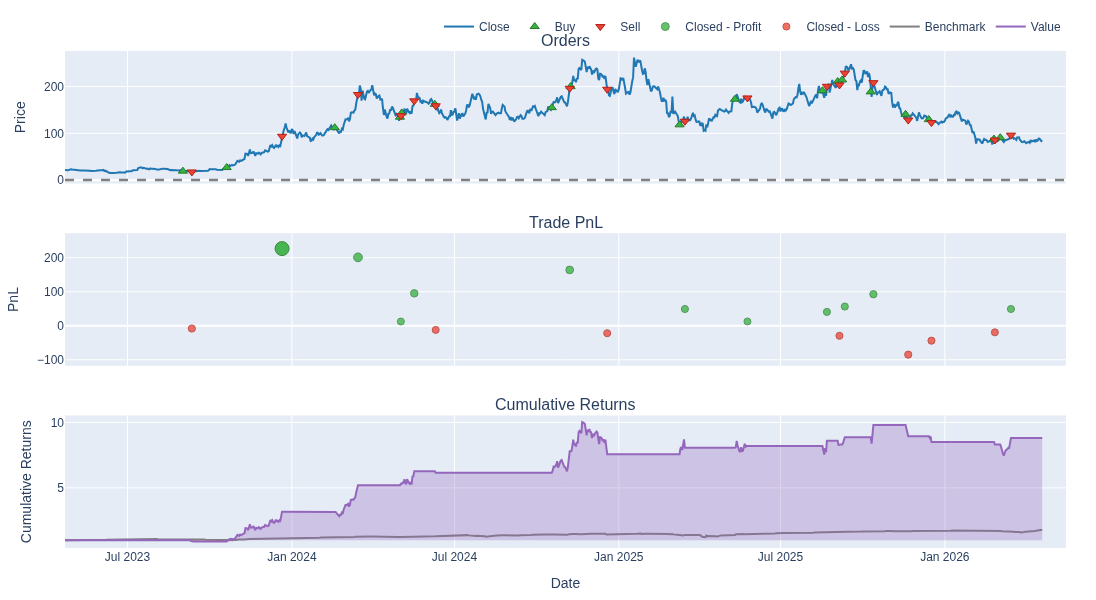

In [18]:
symbol = 'SOL-USD'
fig = vbt.make_subplots(rows=3, cols=1, vertical_spacing=0.1, shared_xaxes=True,
    subplot_titles=[
        "Orders",
        "Trade PnL",
        "Cumulative Returns"
    ])
pf1.plot_orders(column=symbol, 
              add_trace_kwargs=dict(row=1, col=1), 
              fig=fig)
pf1.plot_trade_pnl(column=symbol, 
              add_trace_kwargs=dict(row=2, col=1), 
              fig=fig)
pf1.plot_cumulative_returns(column=symbol, 
                          bm_returns=calc_returns(bm_close['SPY']),
                          # bm_returns=calc_returns(market_data.get('Close')['NVDA']),
                          add_trace_kwargs=dict(row=3, col=1), 
                          fig=fig)

fig.update_layout(
    yaxis1=dict(title="Price"),
    yaxis2=dict(title="PnL"),
    yaxis3=dict(title="Cumulative Returns"),
    xaxis3=dict(title="Date"),
)
fig.update_layout(width=900,height=600)

fig.show()

In [19]:
#display(pf1[symbol].stats())

This strategy demonstrates an ability to outperform buy-and-hold S&P500 ETF over the past three years. It stays short in a major downtrend early 2025, and has its biggest exit in Q4 2023, when Solana performed very well in general.

Although the backtest gave us good news for the Solana strategy, is it a fairytale? Did we overfit to the training data?
The performance is suspiciously good, we may have overfit to the training data. We simulate portfolios using this strategy with the optimal parameter combination in different market regimes, and gather the same metrics.
For simplicty, if the S&P 500 is in an uptrend, we consider this a bull-market, and vice-versa.

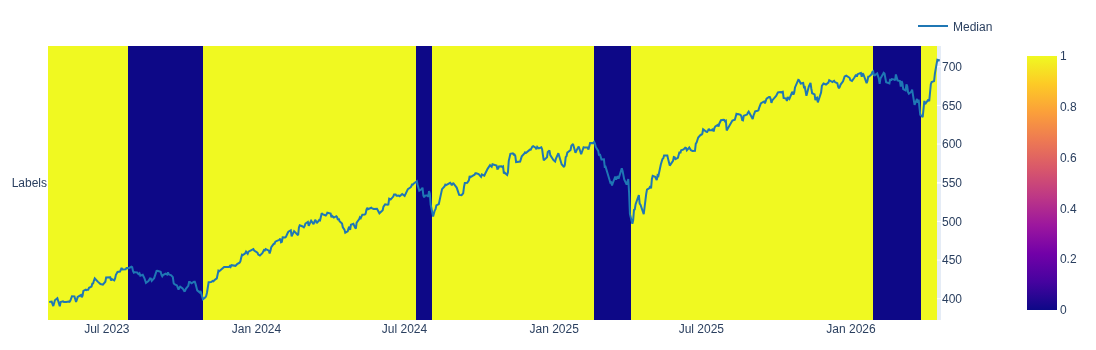

In [20]:
symbol='SPY'
trendlb_conf = {}
trendlb_conf['up_th'] = 0.1
trendlb_conf['down_th'] = 0.09

trendlb = benchmarks.run("trendlb", trendlb_conf['up_th'], trendlb_conf['down_th'])
sym_trend = trendlb.select_col((trendlb_conf['up_th'], trendlb_conf['down_th'], symbol))
sym_trend.plot().show()

In [21]:
grouper = pd.Index(sym_trend.labels.map({1: "U", 0: "D"}), name="trend")
trend_splitter = vbt.Splitter.from_grouper(benchmarks.index, grouper)
trend_splitter = trend_splitter.break_up_splits("by_gap", sort=True)

In [22]:
symbol = 'SOL-USD'
n = len(trend_splitter.split_labels)
labels = trend_splitter.split_labels
rows = []
for i in range(n):
    split = trend_splitter.splits_arr[i]
    period_data = market_data[split[0]]
    trend = labels[i][0]
    period_str = f"{trend} {period_data.index[0].strftime('%Y-%m-%d')} to {period_data.index[-1].strftime('%Y-%m-%d')}"
    
    inputs = best_portfolios.iloc[0].name
    kama_fast = KAMA.run(period_data.get('Close'), period=inputs[0])
    kama_slow = KAMA.run(period_data.get('Close'), period=inputs[1])
    adx = ADX.run(period_data.get('High'), period_data.get('Low'), period_data.get('Close'), 
                  di_ma_len=inputs[2],
                  adx_ma_len=inputs[3])
    adx_thrsh= inputs[4]
    signals = get_signals_analysis(kama_fast, kama_slow, adx, adx_thrsh)
    pf1 = vbt.Portfolio.from_signals(
        period_data.get('Close'),
        entries=signals[0],
        exits=signals[1]
    )
    rows.append({
        'trend': trend,
        'period_start': period_data.index[0],
        'period_end': period_data.index[-1],
        'Sharpe Ratio' : pf1[symbol].sharpe_ratio,
        'Sortino Ratio': pf1[symbol].sortino_ratio,
        'Max Drawdown': pf1[symbol].max_drawdown,
        'Ann Returns': pf1[symbol].annualized_return,
    })
df1 = pd.DataFrame(rows).dropna()

In [23]:
df1

,trend,period_start,period_end,Sharpe Ratio,Sortino Ratio,Max Drawdown,Ann Returns
2,U,2023-08-31 00:00:00+00:00,2024-02-24 00:00:00+00:00,3.517746,8.104455,-0.206516,10.020272
4,U,2024-03-10 00:00:00+00:00,2024-07-22 00:00:00+00:00,0.737757,1.160272,-0.185497,0.266873
6,U,2024-08-25 00:00:00+00:00,2025-03-15 00:00:00+00:00,0.712202,1.137939,-0.244223,0.219068


The strategy only places trades in bull market regimes for this dataset. One performs astronomically well and the other two have sharpe ratios below 1. This analysis demonstrates that although the backtest looked promising, this strategy lacks risk-controls for market outperformance in bear markets (since shorting assets is not permitted).